Interpolation: Estimating values between known data points, creating continuous function that fits given points
- Linear Interpolation: Assumes straight line between two points, which might be jagged or poor accuracy
- Polynomial Interpolation: Fits single polynomial to all data points (high degree polynomials could oscillate a lot so keep it to third power at most

Spline Interpolation: Piecewise polynomial function that maintains smoothness at the data points (knots). Instead of using one polynomial for all data points, spline interpolation fits multiple lower-degree polynomials between each pair of points.

Cubic Spline: Piecewise cubic polynomial, fits cubic polynomials between consecutive data points, ensures smoothness at data points (knots), more stable with no overfitting or osciallations

Conditions:
- Interpolation: Spline passes through given points
- Continuity of first and second derivatives: Continuous at the internal points
- Boundary Conditions: 
  1. Natural Spline: Second derivative at endpoints is 0
  2. Clamped Spline: First derivatives at endpoints are specified

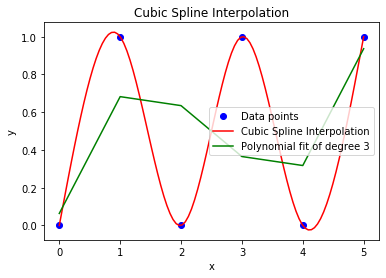

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define known data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

# Create a cubic spline interpolation of the data
cs = CubicSpline(x, y, bc_type='natural')

# Generate new x values for a smooth plot
x_interp = np.linspace(0, 5, 100)
y_interp = cs(x_interp)

# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

# Plot the original data and cubic spline interpolation
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_interp, 'r-', label="Cubic Spline Interpolation")
plt.plot(x, y_pred, color='g', label=f'Polynomial fit of degree {degree}')
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Challenge: The polynomial fit is much less smooth, while the cublic spline seems to be more smooth and has the points fit better into the shape of the graph.

Not overfit because we are not manipulating polynomial to fit, trusted data points are used in a general method.

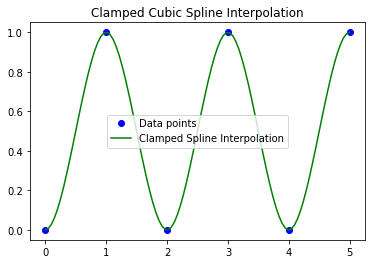

In [11]:
# Create a clamped cubic spline interpolation
cs_clamped = CubicSpline(x, y, bc_type=((1, 0), (1, 0)))

# Interpolated points
y_clamped_interp = cs_clamped(x_interp)

# Plot the clamped cubic spline interpolation
plt.plot(x, y, 'bo', label="Data points")
plt.plot(x_interp, y_clamped_interp, 'g-', label="Clamped Spline Interpolation")
plt.title("Clamped Cubic Spline Interpolation")
plt.legend()
plt.show()

Challenge:

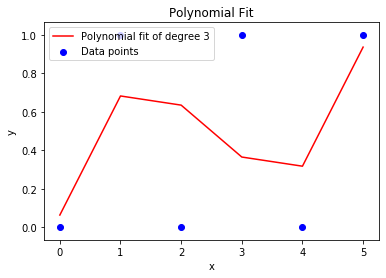

In [9]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()